NAME: ALOK KUMAR MAVI

SECTION: B

ROLL.NO.: 05

CU ID: CU240251681

# LAB SHEET - 10

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:
df = sns.load_dataset("taxis")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (6433, 14)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 6433
Number of columns: 14

Column names:
['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls', 'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [5]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
dropoff_zone,45,0.699518
dropoff_borough,45,0.699518
payment,44,0.683973
pickup_zone,26,0.404166
pickup_borough,26,0.404166
pickup,0,0.000000
tip,0,0.000000
fare,0,0.000000
distance,0,0.000000
passengers,0,0.000000


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (6433, 14)


In [9]:
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [11]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [13]:
df["pickup"] = pd.to_datetime(df["pickup"])
df["dropoff"] = pd.to_datetime(df["dropoff"])

In [14]:
df["duration_minutes"] = (
    df["dropoff"] - df["pickup"]
).dt.total_seconds() / 60

In [15]:
df["pickup_hour"] = df["pickup"].dt.hour
df["pickup_day"] = df["pickup"].dt.day_name()
df["pickup_date"] = df["pickup"].dt.date

In [16]:
df[[
    "pickup",
    "dropoff",
    "duration_minutes",
    "pickup_hour",
    "pickup_day"
]].head()

,pickup,dropoff,duration_minutes,pickup_hour,pickup_day
0,2019-03-23 20:21:09,2019-03-23 20:27:24,6.250000,20,Saturday
1,2019-03-04 16:11:55,2019-03-04 16:19:00,7.083333,16,Monday
2,2019-03-27 17:53:01,2019-03-27 18:00:25,7.400000,17,Wednesday
3,2019-03-10 01:23:59,2019-03-10 01:49:51,25.866667,1,Sunday
4,2019-03-30 13:27:42,2019-03-30 13:37:14,9.533333,13,Saturday


In [17]:
df = df[
    (df["distance"] > 0) &
    (df["fare"] > 0) &
    (df["duration_minutes"] > 0)
].copy()

print("Shape after removing invalid records:", df.shape)

Shape after removing invalid records: (6382, 18)


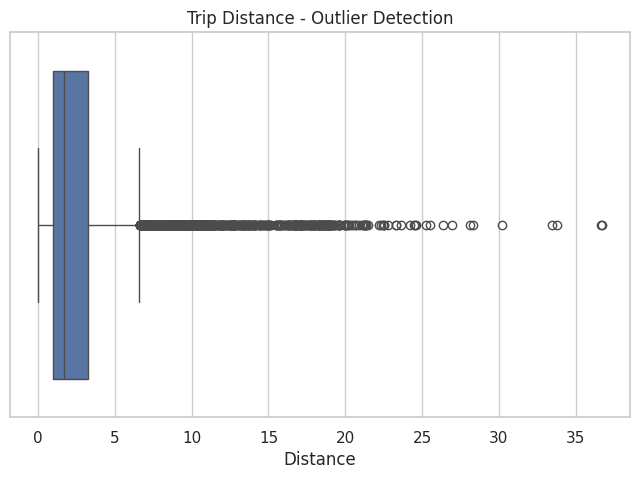

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["distance"])

plt.title("Trip Distance - Outlier Detection")
plt.xlabel("Distance")

plt.show()

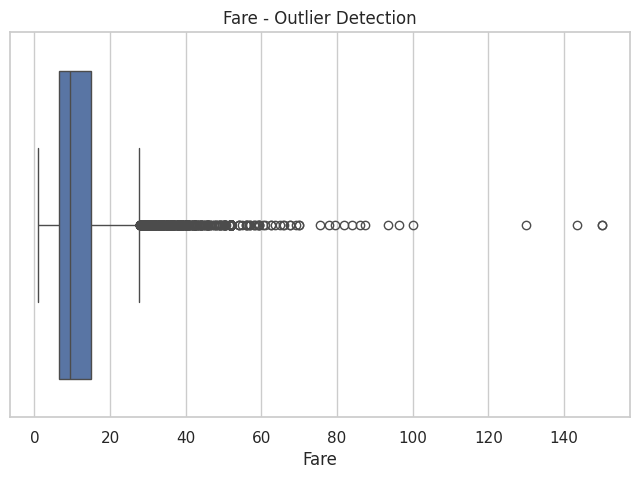

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["fare"])

plt.title("Fare - Outlier Detection")
plt.xlabel("Fare")

plt.show()

In [20]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[
        (data[column] >= lower) &
        (data[column] <= upper)
    ]

df = remove_outliers(df, "distance")
df = remove_outliers(df, "fare")
df = remove_outliers(df, "duration_minutes")

print("Shape after outlier treatment:", df.shape)

Shape after outlier treatment: (5458, 18)


In [21]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,duration_minutes,pickup_hour,pickup_day,pickup_date
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,6.250000,20,Saturday,2019-03-23
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,7.083333,16,Monday,2019-03-04
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,7.400000,17,Wednesday,2019-03-27
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,9.533333,13,Saturday,2019-03-30
5,2019-03-11 10:37:23,2019-03-11 10:47:31,1,0.49,7.5,2.16,0.0,12.96,yellow,credit card,Times Sq/Theatre District,Midtown East,Manhattan,Manhattan,10.133333,10,Monday,2019-03-11


In [22]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,duration_minutes,pickup_hour
count,5458,5458,5458.000000,5458.000000,5458.000000,5458.000000,5458.000000,5458.000000,5458.000000,5458.000000
mean,2019-03-16 08:59:19.309087488,2019-03-16 09:10:10.350494720,1.544155,1.794725,9.306783,1.580183,0.012624,14.103914,10.850690,13.961158
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.010000,1.000000,0.000000,0.000000,1.300000,0.066667,0.000000
25%,2019-03-08 16:19:22.249999872,2019-03-08 16:28:17,1.000000,0.900000,6.000000,0.000000,0.000000,10.300000,6.050000,10.000000
50%,2019-03-15 21:51:48.500000,2019-03-15 22:07:28,1.000000,1.430000,8.500000,1.660000,0.000000,12.960000,9.583333,15.000000
75%,2019-03-23 18:41:49.500000,2019-03-23 18:59:28.750000128,2.000000,2.327500,12.000000,2.550000,0.000000,17.160000,14.716667,19.000000
max,2019-03-31 23:15:03,2019-03-31 23:27:12,6.000000,6.600000,22.000000,8.250000,5.760000,36.320000,28.433333,23.000000
std,NaN,NaN,1.207746,1.228738,4.143581,1.433817,0.268966,5.084467,6.137639,6.082654


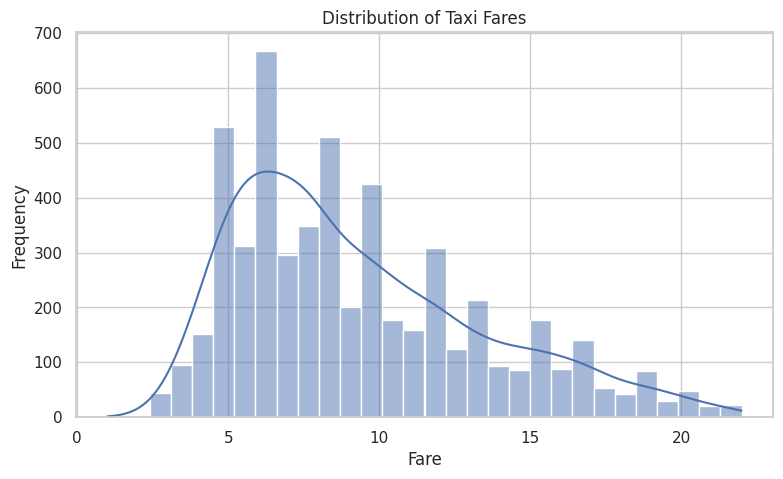

In [23]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["fare"],
    bins=30,
    kde=True
)

plt.title("Distribution of Taxi Fares")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

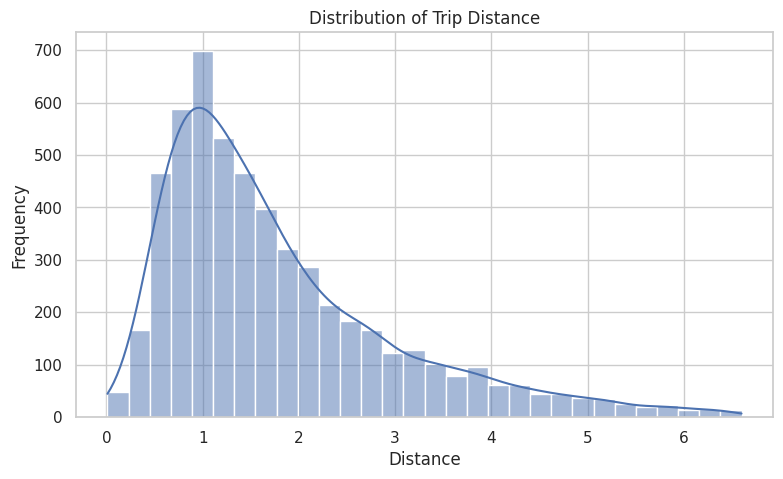

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["distance"],
    bins=30,
    kde=True
)

plt.title("Distribution of Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

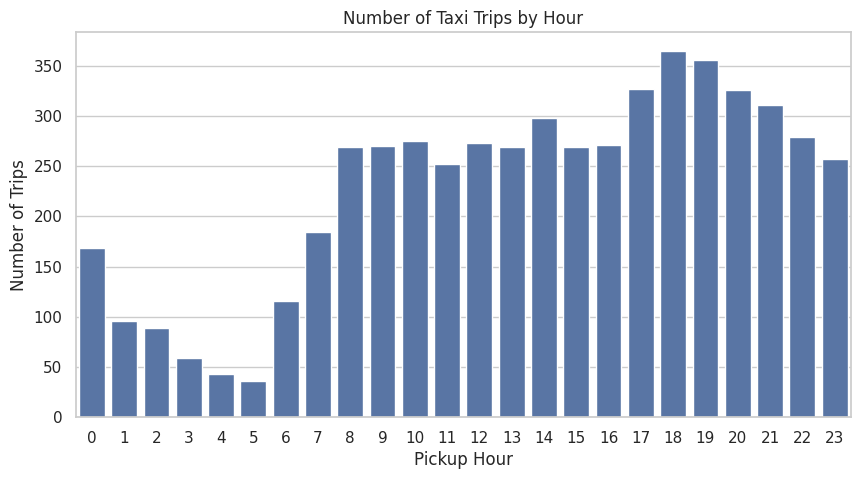

In [25]:
hourly_trips = df["pickup_hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=hourly_trips.index,
    y=hourly_trips.values
)

plt.title("Number of Taxi Trips by Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")

plt.show()

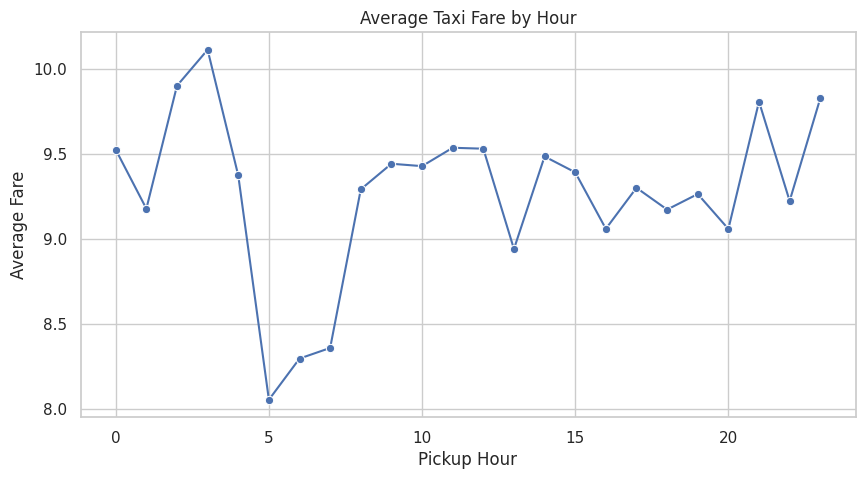

In [26]:
hourly_fare = df.groupby("pickup_hour")["fare"].mean()

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hourly_fare.index,
    y=hourly_fare.values,
    marker="o"
)

plt.title("Average Taxi Fare by Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Fare")

plt.show()

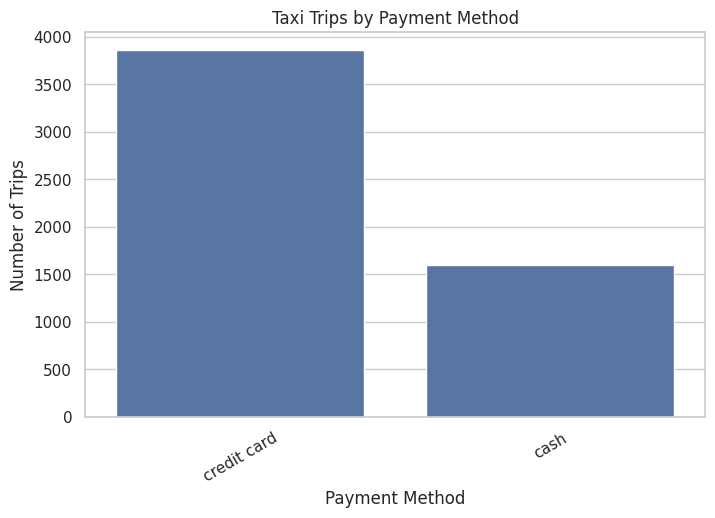

In [27]:
payment_counts = df["payment"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Taxi Trips by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Trips")

plt.xticks(rotation=30)

plt.show()

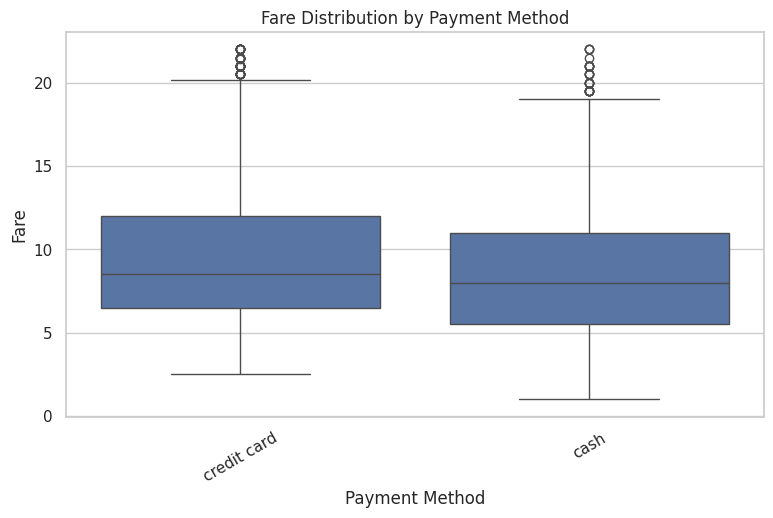

In [28]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="payment",
    y="fare"
)

plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")

plt.xticks(rotation=30)

plt.show()

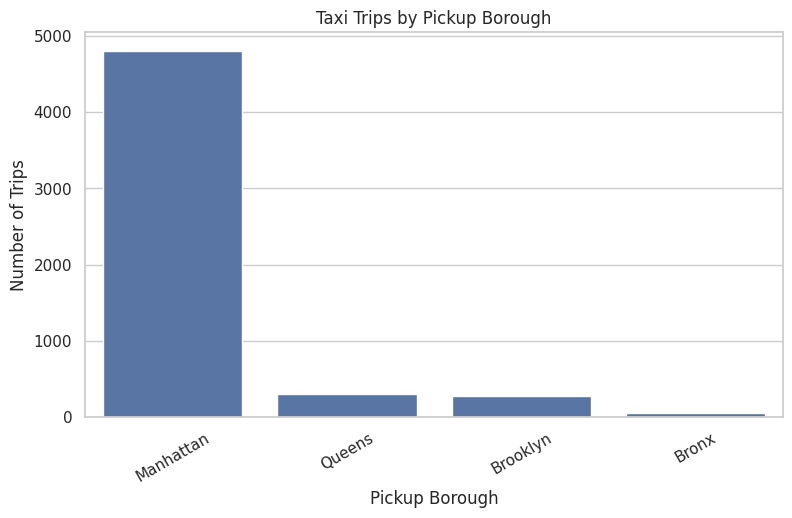

In [29]:
borough_counts = df["pickup_borough"].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=borough_counts.index,
    y=borough_counts.values
)

plt.title("Taxi Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")

plt.xticks(rotation=30)

plt.show()

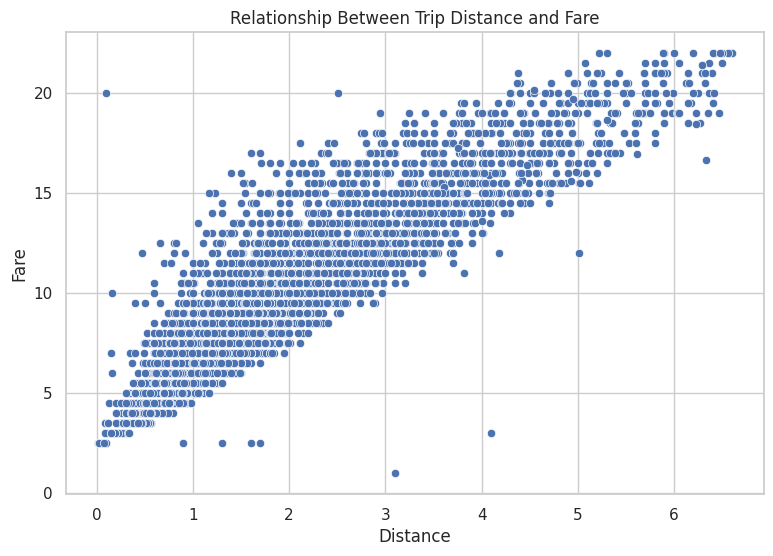

In [30]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare"
)

plt.title("Relationship Between Trip Distance and Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")

plt.show()

In [31]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,passengers,distance,fare,tip,tolls,total,duration_minutes,pickup_hour
passengers,1.000000,0.016109,0.014862,0.032867,-0.018025,0.035401,0.015551,-0.010168
distance,0.016109,1.000000,0.910060,0.320464,0.116633,0.834264,0.733636,-0.009851
fare,0.014862,0.910060,1.000000,0.357864,0.085262,0.923840,0.934521,0.012841
tip,0.032867,0.320464,0.357864,1.000000,0.057479,0.638288,0.335019,0.056650
tolls,-0.018025,0.116633,0.085262,0.057479,1.000000,0.129057,0.035423,0.032583
total,0.035401,0.834264,0.923840,0.638288,0.129057,1.000000,0.867634,0.062761
duration_minutes,0.015551,0.733636,0.934521,0.335019,0.035423,0.867634,1.000000,0.041279
pickup_hour,-0.010168,-0.009851,0.012841,0.056650,0.032583,0.062761,0.041279,1.000000


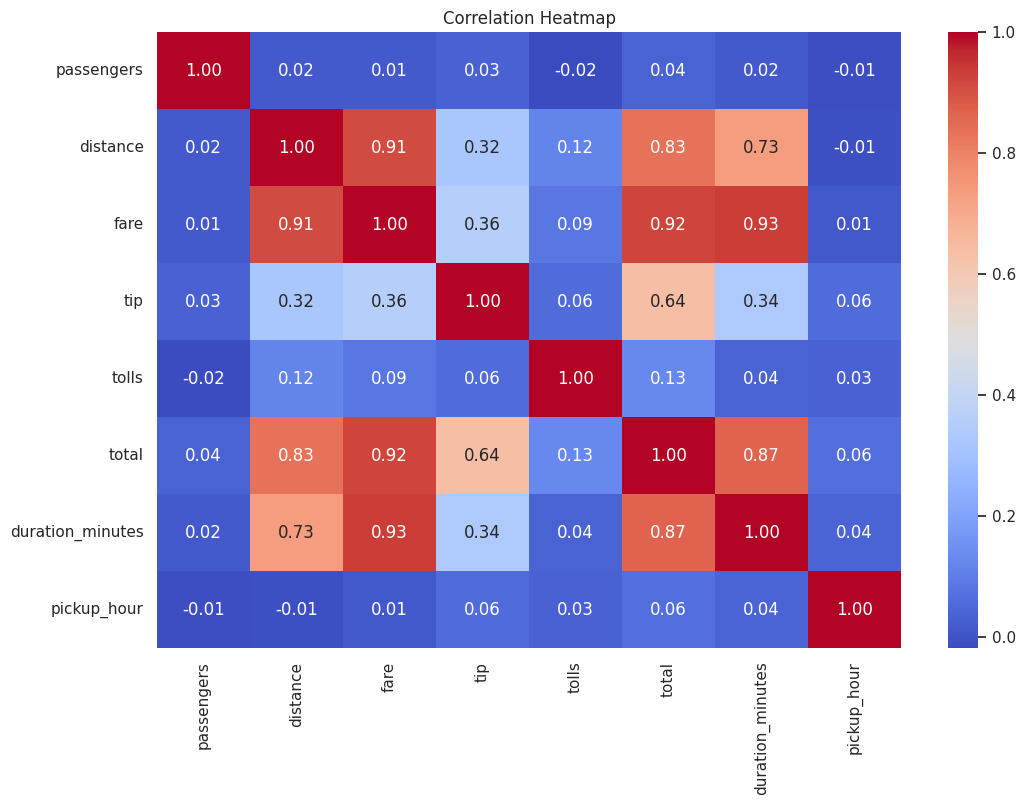

In [32]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [33]:
print(df["payment"].value_counts())

payment
credit card    3857
cash           1601
Name: count, dtype: int64


In [34]:
credit_card = df[
    df["payment"].str.lower().str.contains("credit", na=False)
]["duration_minutes"]

cash = df[
    df["payment"].str.lower().str.contains("cash", na=False)
]["duration_minutes"]

In [35]:
t_stat, p_value = ttest_ind(
    credit_card,
    cash,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.727744039394622
P-value: 2.3746190997619756e-06


In [36]:
if p_value < 0.05:
    print("The difference in trip duration between the two payment groups is statistically significant.")
else:
    print("The difference in trip duration between the two payment groups is not statistically significant.")

The difference in trip duration between the two payment groups is statistically significant.


In [37]:
model_df = df[
    [
        "distance",
        "duration_minutes",
        "passengers",
        "tolls",
        "tip",
        "fare"
    ]
].copy()

model_df.head()

,distance,duration_minutes,passengers,tolls,tip,fare
0,1.60,6.250000,1,0.0,2.15,7.0
1,0.79,7.083333,1,0.0,0.00,5.0
2,1.37,7.400000,1,0.0,2.36,7.5
4,2.16,9.533333,3,0.0,1.10,9.0
5,0.49,10.133333,1,0.0,2.16,7.5


In [38]:
model_df = model_df.dropna()

print("Model dataset shape:", model_df.shape)

Model dataset shape: (5458, 6)


In [39]:
X = model_df.drop("fare", axis=1)
y = model_df["fare"]

print("Features:")
print(X.columns.tolist())

print("\nTarget: fare")

Features:
['distance', 'duration_minutes', 'passengers', 'tolls', 'tip']

Target: fare


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4366
Testing samples: 1092


In [41]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [42]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[ 5.86700954  5.39236084 13.33651393 12.87297892  7.60325712 10.25812772
  5.15413115 16.84168515 16.88781794  3.8360956 ]


In [43]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("=" * 30)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

Model Performance
MAE  : 0.30
RMSE : 0.69
R²   : 0.972


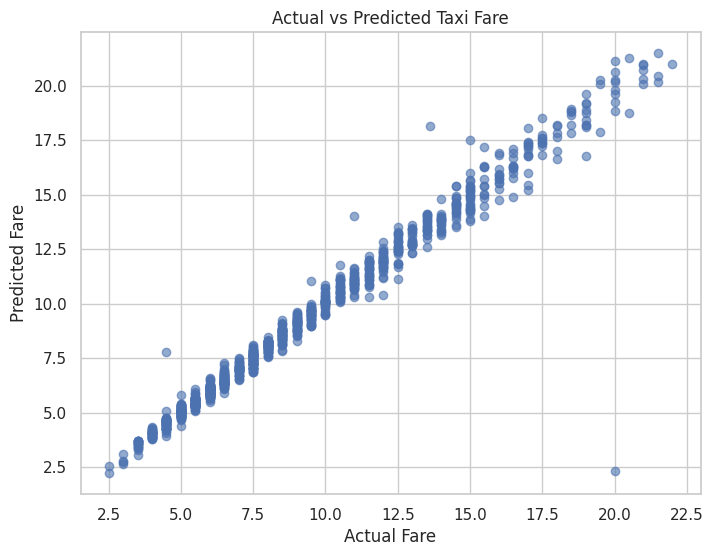

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Taxi Fare")

plt.show()

In [45]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
0,distance,1.627826
1,duration_minutes,0.390197
3,tolls,0.090136
4,tip,0.029969
2,passengers,-0.003869


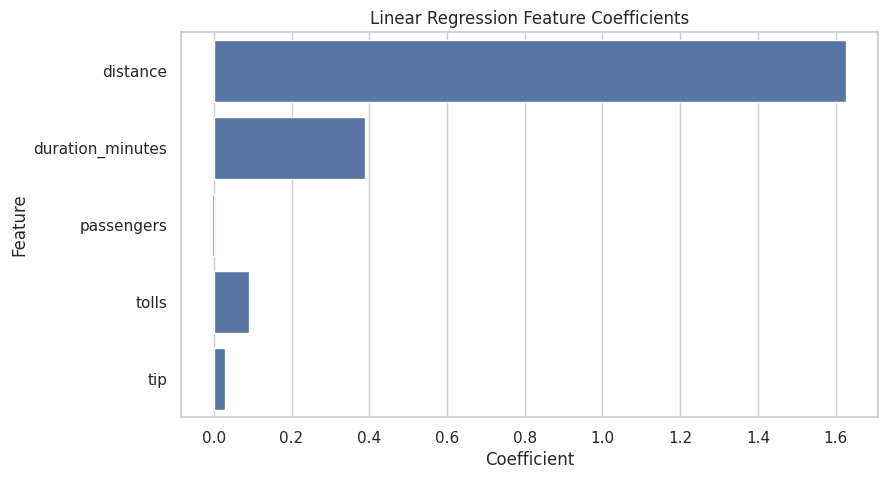

In [46]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Coefficients")

plt.show()

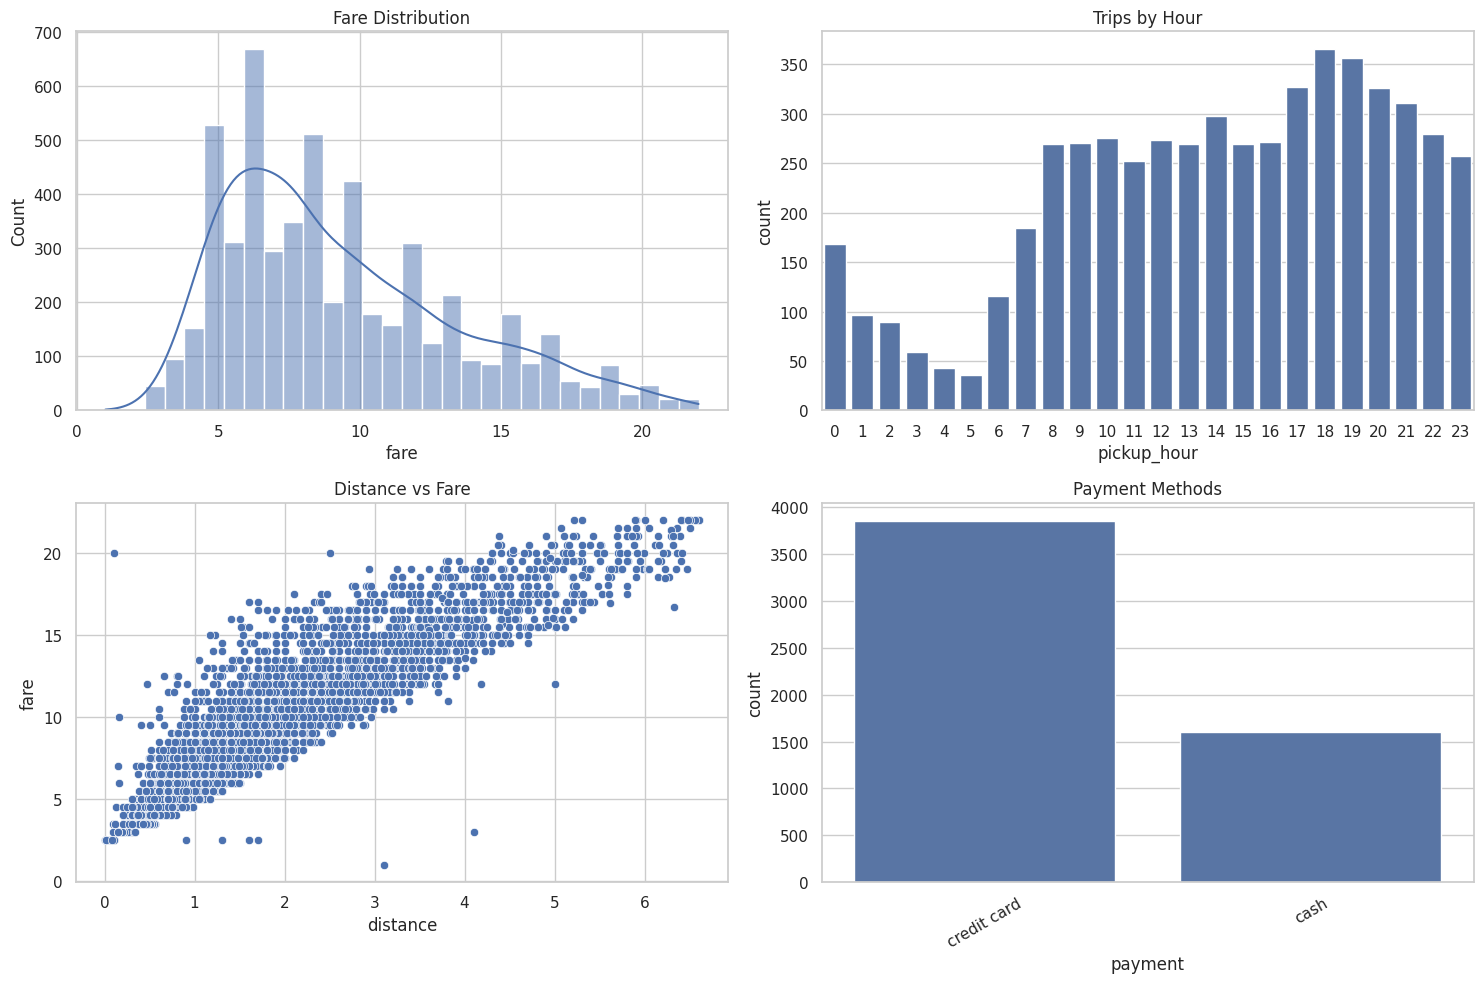

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Fare distribution
sns.histplot(
    df["fare"],
    bins=30,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Fare Distribution")

# 2. Trips by hour
sns.countplot(
    data=df,
    x="pickup_hour",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Trips by Hour")

# 3. Distance vs fare
sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Distance vs Fare")

# 4. Trips by payment method
sns.countplot(
    data=df,
    x="payment",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Payment Methods")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [48]:
print("KEY ANALYTICAL INSIGHTS")
print("=" * 50)

print(f"Total cleaned trips analyzed: {len(df):,}")

print(f"\nAverage trip distance: {df['distance'].mean():.2f}")

print(f"Average fare: {df['fare'].mean():.2f}")

print(f"Average trip duration: {df['duration_minutes'].mean():.2f} minutes")

print("\nMost common payment method:")
print(df["payment"].mode()[0])

print("\nBorough with the highest number of pickup trips:")
print(df["pickup_borough"].value_counts().idxmax())

print("\nMachine Learning Performance")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

KEY ANALYTICAL INSIGHTS
Total cleaned trips analyzed: 5,458

Average trip distance: 1.79
Average fare: 9.31
Average trip duration: 10.85 minutes

Most common payment method:
credit card

Borough with the highest number of pickup trips:
Manhattan

Machine Learning Performance
MAE  : 0.30
RMSE : 0.69
R²   : 0.972


In [49]:
results = pd.DataFrame({
    "Metric": [
        "Total Trips",
        "Average Distance",
        "Average Fare",
        "Average Duration",
        "MAE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        len(df),
        round(df["distance"].mean(), 2),
        round(df["fare"].mean(), 2),
        round(df["duration_minutes"].mean(), 2),
        round(mae, 2),
        round(rmse, 2),
        round(r2, 3)
    ]
})

results

,Metric,Value
0,Total Trips,5458.000
1,Average Distance,1.790
2,Average Fare,9.310
3,Average Duration,10.850
4,MAE,0.300
5,RMSE,0.690
6,R² Score,0.972


## Experiment 10 — Questions and Answers

### 1. What are the major stages involved in an end-to-end data analytics project?

**Answer:**
The major stages are data collection, data preprocessing, exploratory data analysis (EDA), statistical analysis, data visualization, machine learning model development, model evaluation, interpretation of results, and presentation of actionable insights.

---

### 2. Why is data preprocessing considered the foundation of successful analytics and machine learning?

**Answer:**
Data preprocessing improves the quality and reliability of data before analysis. It involves handling missing values, removing duplicates, treating outliers, and converting categorical data into a suitable format. Clean and properly prepared data helps produce more accurate and reliable analytical and machine learning results.

---

### 3. How does Exploratory Data Analysis (EDA) contribute to model development?

**Answer:**
EDA helps understand the structure and characteristics of a dataset using statistics and visualizations. It identifies patterns, relationships, missing values, outliers, and important variables. These findings help in selecting suitable features, preprocessing techniques, and machine learning algorithms.

---

### 4. What factors should be considered while selecting a machine learning algorithm for a business problem?

**Answer:**
The type of problem, size and quality of the dataset, type of variables, expected output, model complexity, interpretability, computational requirements, and required accuracy should be considered. The selected algorithm should also be appropriate for classification, regression, or clustering depending on the problem.

---

### 5. Why is model evaluation essential before deploying a predictive model?

**Answer:**
Model evaluation determines how well a model performs on unseen data. It helps identify errors and whether the model is reliable enough for practical use. Metrics such as Accuracy, Precision, Recall, F1-Score, MAE, RMSE, and R² can be used depending on the type of model.

---

### 6. Explain how Business Intelligence tools complement machine learning in data analytics projects.

**Answer:**
Business Intelligence tools help present analytical and machine learning results through dashboards, charts, and interactive reports. Machine learning provides predictions and patterns, while BI tools make these results easier for decision-makers to understand and use for business planning.

---

### 7. What challenges are commonly encountered while working with real-world datasets?

**Answer:**
Common challenges include missing values, duplicate records, outliers, inconsistent data formats, categorical variables, noisy data, large dataset sizes, and unreliable or incomplete information. These issues must be addressed during preprocessing to obtain meaningful results.

---

### 8. How can analytical insights be converted into actionable business recommendations?

**Answer:**
Analytical results should first be interpreted to identify important trends, relationships, opportunities, and risks. These findings can then be translated into specific actions, such as improving services, optimizing resources, targeting customers, reducing costs, or improving operational efficiency.

---

### 9. Why is effective presentation and data storytelling important in analytics projects?

**Answer:**
Data storytelling converts complex analytical results into a clear and understandable message. Effective visualizations and explanations help stakeholders quickly understand important trends, findings, and recommendations, allowing them to make informed decisions.

---

### 10. Suggest future improvements or advanced techniques that could enhance the accuracy and effectiveness of the developed analytics solution.

**Answer:**
Future improvements could include using larger and more recent datasets, advanced feature engineering, hyperparameter tuning, ensemble models, cross-validation, and more advanced machine learning algorithms. Interactive dashboards using Power BI or Tableau could also improve presentation and decision-making.
